In [21]:
pip install faker

In [22]:
import pandas as pd
from faker import Faker
import random

fake = Faker()

num_records = 1000

data = []

for i in range(num_records):
    customer_id = f"C{i+1:04d}"
    name = fake.name()
    age = random.randint(18, 70)
    gender = random.choice(["Male", "Female"])
    city = fake.city()
    email = fake.email()
    phone = fake.phone_number()

    tenure = random.randint(1, 72)  # months
    monthly_charges = random.randint(300, 2500)
    total_charges = tenure * monthly_charges

    contract_type = random.choice(["Monthly", "Yearly", "Two-Year"])
    internet_service = random.choice(["Fiber", "DSL", "None"])
    support_calls = random.randint(0, 10)

    # Churn Logic (realistic)
    churn = 1 if (tenure < 12 and contract_type == "Monthly" and support_calls > 3) else 0

    data.append([
        customer_id, name, age, gender, city, email, phone,
        tenure, monthly_charges, total_charges,
        contract_type, internet_service, support_calls, churn
    ])

columns = [
    "Customer_ID", "Name", "Age", "Gender", "City", "Email", "Phone",
    "Tenure", "Monthly_Charges", "Total_Charges",
    "Contract_Type", "Internet_Service", "Support_Calls", "Churn"
]

df = pd.DataFrame(data, columns=columns)

# Save as CSV (Database file)
df.to_csv("customer_churn_database.csv", index=False)

print("Customer Churn Database Created!")
print(df.head())

Customer Churn Database Created!
  Customer_ID                   Name  Age  Gender               City  \
0       C0001          Brandon Weiss   62  Female  South Brandyville   
1       C0002           Rhonda Hayes   59  Female       Williamsstad   
2       C0003           Willie Lopez   33    Male          Kevinland   
3       C0004          Diana Mathews   66    Male       Hancockhaven   
4       C0005  Jacqueline Montgomery   62  Female         Hannahview   

                      Email               Phone  Tenure  Monthly_Charges  \
0  marshdeborah@example.org       (921)432-6993      64             1570   
1     ywilliams@example.org  (634)455-4405x9380      38             2375   
2        bdavis@example.org   332-538-9834x9119      49             2247   
3     bryanwall@example.net       (966)652-0656      41             1304   
4     chadperez@example.net        436.478.2402      34              699   

   Total_Charges Contract_Type Internet_Service  Support_Calls  Churn  
0    

In [23]:
display(df.head())

,Customer_ID,Name,Age,Gender,City,Email,Phone,Tenure,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Support_Calls,Churn
0,C0001,Brandon Weiss,62,Female,South Brandyville,marshdeborah@example.org,(921)432-6993,64,1570,100480,Two-Year,Fiber,2,0
1,C0002,Rhonda Hayes,59,Female,Williamsstad,ywilliams@example.org,(634)455-4405x9380,38,2375,90250,Monthly,Fiber,5,0
2,C0003,Willie Lopez,33,Male,Kevinland,bdavis@example.org,332-538-9834x9119,49,2247,110103,Yearly,DSL,0,0
3,C0004,Diana Mathews,66,Male,Hancockhaven,bryanwall@example.net,(966)652-0656,41,1304,53464,Monthly,Fiber,8,0
4,C0005,Jacqueline Montgomery,62,Female,Hannahview,chadperez@example.net,436.478.2402,34,699,23766,Yearly,Fiber,7,0


In [24]:
print(df.isnull().sum())

Customer_ID         0
Name                0
Age                 0
Gender              0
City                0
Email               0
Phone               0
Tenure              0
Monthly_Charges     0
Total_Charges       0
Contract_Type       0
Internet_Service    0
Support_Calls       0
Churn               0
dtype: int64


In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Customer_ID       1000 non-null   object
 1   Name              1000 non-null   object
 2   Age               1000 non-null   int64 
 3   Gender            1000 non-null   object
 4   City              1000 non-null   object
 5   Email             1000 non-null   object
 6   Phone             1000 non-null   object
 7   Tenure            1000 non-null   int64 
 8   Monthly_Charges   1000 non-null   int64 
 9   Total_Charges     1000 non-null   int64 
 10  Contract_Type     1000 non-null   object
 11  Internet_Service  1000 non-null   object
 12  Support_Calls     1000 non-null   int64 
 13  Churn             1000 non-null   int64 
dtypes: int64(6), object(8)
memory usage: 109.5+ KB
None


In [26]:
for column in ['Gender', 'Contract_Type', 'Internet_Service']:
    print(f"Unique values for {column}: {df[column].unique()}")

Unique values for Gender: ['Female' 'Male']
Unique values for Contract_Type: ['Two-Year' 'Monthly' 'Yearly']
Unique values for Internet_Service: ['Fiber' 'DSL' 'None']


In [27]:
import pandas as pd

# Select categorical columns to encode
categorical_cols_to_encode = ['Gender', 'Contract_Type', 'Internet_Service']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# Display the first few rows of the encoded DataFrame and its info to verify
print("DataFrame after one-hot encoding:")
display(df_encoded.head())
print("\nInfo of the encoded DataFrame:")
print(df_encoded.info())

DataFrame after one-hot encoding:


,Customer_ID,Name,Age,City,Email,Phone,Tenure,Monthly_Charges,Total_Charges,Support_Calls,Churn,Gender_Male,Contract_Type_Two-Year,Contract_Type_Yearly,Internet_Service_Fiber,Internet_Service_None
0,C0001,Brandon Weiss,62,South Brandyville,marshdeborah@example.org,(921)432-6993,64,1570,100480,2,0,False,True,False,True,False
1,C0002,Rhonda Hayes,59,Williamsstad,ywilliams@example.org,(634)455-4405x9380,38,2375,90250,5,0,False,False,False,True,False
2,C0003,Willie Lopez,33,Kevinland,bdavis@example.org,332-538-9834x9119,49,2247,110103,0,0,True,False,True,False,False
3,C0004,Diana Mathews,66,Hancockhaven,bryanwall@example.net,(966)652-0656,41,1304,53464,8,0,True,False,False,True,False
4,C0005,Jacqueline Montgomery,62,Hannahview,chadperez@example.net,436.478.2402,34,699,23766,7,0,False,False,True,True,False



Info of the encoded DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Customer_ID             1000 non-null   object
 1   Name                    1000 non-null   object
 2   Age                     1000 non-null   int64 
 3   City                    1000 non-null   object
 4   Email                   1000 non-null   object
 5   Phone                   1000 non-null   object
 6   Tenure                  1000 non-null   int64 
 7   Monthly_Charges         1000 non-null   int64 
 8   Total_Charges           1000 non-null   int64 
 9   Support_Calls           1000 non-null   int64 
 10  Churn                   1000 non-null   int64 
 11  Gender_Male             1000 non-null   bool  
 12  Contract_Type_Two-Year  1000 non-null   bool  
 13  Contract_Type_Yearly    1000 non-null   bool  
 14  Internet_Service_Fiber  1

In [28]:
numerical_cols_encoded = df_encoded.select_dtypes(include=['int64', 'float64', 'bool']).columns
display(df_encoded[numerical_cols_encoded].describe())

,Age,Tenure,Monthly_Charges,Total_Charges,Support_Calls,Churn
count,1000.000000,1000.000000,1000.0000,1000.00000,1000.000000,1000.000000
mean,43.064000,36.080000,1400.5460,50718.75900,4.872000,0.031000
std,15.057311,21.027072,632.5491,39321.69972,3.159683,0.173404
min,18.000000,1.000000,303.0000,306.00000,0.000000,0.000000
25%,30.000000,18.000000,878.7500,17788.50000,2.000000,0.000000
50%,43.000000,35.500000,1409.5000,41357.50000,5.000000,0.000000
75%,56.000000,54.000000,1941.2500,76958.00000,8.000000,0.000000
max,70.000000,72.000000,2498.0000,177358.00000,10.000000,1.000000


In [29]:
for col in numerical_cols_encoded:
    print(f"Mode of {col}: {df_encoded[col].mode()[0]}")

Mode of Age: 35
Mode of Tenure: 34
Mode of Monthly_Charges: 1773
Mode of Total_Charges: 1058
Mode of Support_Calls: 4
Mode of Churn: 0
Mode of Gender_Male: True
Mode of Contract_Type_Two-Year: False
Mode of Contract_Type_Yearly: False
Mode of Internet_Service_Fiber: False
Mode of Internet_Service_None: False


Churn Distribution (Counts):
Churn
0    969
1     31
Name: count, dtype: int64

Churn Distribution (Percentage):
Churn
0    96.9
1     3.1
Name: proportion, dtype: float64


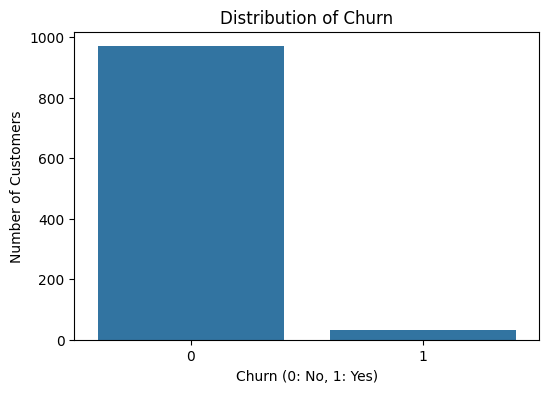

In [30]:
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution (Counts):")
print(churn_counts)
print("\nChurn Distribution (Percentage):")
print(churn_percentage)

# Visualize Churn Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Number of Customers')
plt.show()

Churn Rate by Age Group:
     Age_Group     Churn  Churn_Rate
0        Young  0.012448    1.244813
1  Middle-Aged  0.035533    3.553299
2       Senior  0.034582    3.458213


/tmp/ipykernel_675/1586961417.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('Age_Group')['Churn'].mean().reset_index()
/tmp/ipykernel_675/1586961417.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='Churn_Rate', data=age_churn, palette='viridis')


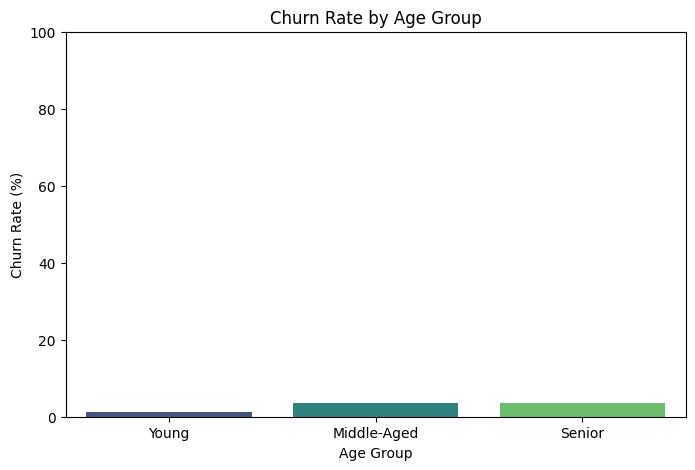

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define age groups
age_bins = [18, 30, 50, 70]
age_labels = ['Young', 'Middle-Aged', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Calculate churn rate by age group
age_churn = df.groupby('Age_Group')['Churn'].mean().reset_index()
age_churn['Churn_Rate'] = age_churn['Churn'] * 100

print("Churn Rate by Age Group:")
print(age_churn)

# Visualize churn rate by age group
plt.figure(figsize=(8, 5))
sns.barplot(x='Age_Group', y='Churn_Rate', data=age_churn, palette='viridis')
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100) # Ensure y-axis is from 0 to 100 for percentage
plt.show()

Churn Rate by Gender:
   Gender     Churn  Churn_Rate
0  Female  0.028689    2.868852
1    Male  0.033203    3.320312


/tmp/ipykernel_675/3334211034.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Churn_Rate', data=gender_churn, palette='coolwarm')


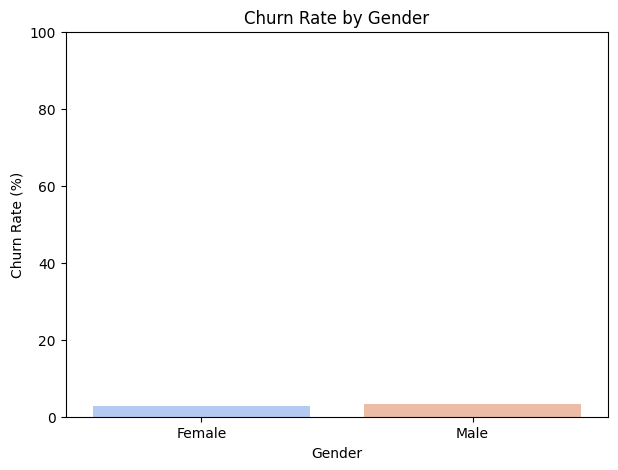

In [32]:
# Calculate churn rate by gender
gender_churn = df.groupby('Gender')['Churn'].mean().reset_index()
gender_churn['Churn_Rate'] = gender_churn['Churn'] * 100

print("Churn Rate by Gender:")
print(gender_churn)

# Visualize churn rate by gender
plt.figure(figsize=(7, 5))
sns.barplot(x='Gender', y='Churn_Rate', data=gender_churn, palette='coolwarm')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

Churn Rate by Tenure Group:
      Tenure_Group     Churn  Churn_Rate
0        New Users  0.186747   18.674699
1   Mid-Term Users  0.000000    0.000000
2  Long-Term Users  0.000000    0.000000


/tmp/ipykernel_675/2743646134.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('Tenure_Group')['Churn'].mean().reset_index()
/tmp/ipykernel_675/2743646134.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tenure_Group', y='Churn_Rate', data=tenure_churn, palette='plasma')


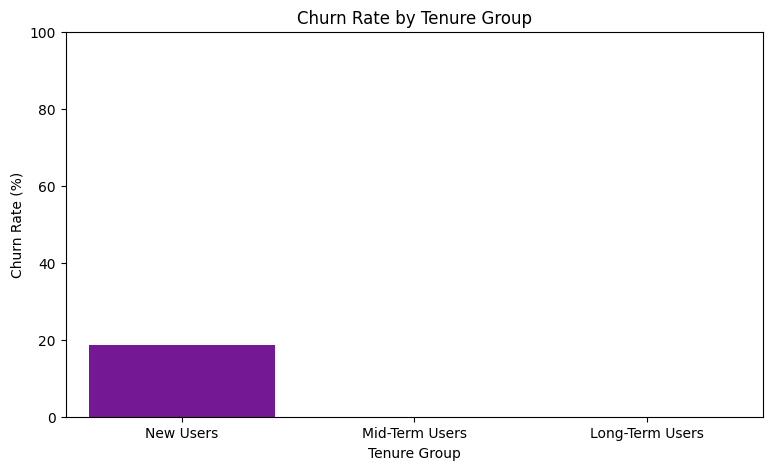

In [33]:
# Define tenure groups
tenure_bins = [0, 12, 36, df['Tenure'].max() + 1] # +1 to include max value
tenure_labels = ['New Users', 'Mid-Term Users', 'Long-Term Users']
df['Tenure_Group'] = pd.cut(df['Tenure'], bins=tenure_bins, labels=tenure_labels, right=False)

# Calculate churn rate by tenure group
tenure_churn = df.groupby('Tenure_Group')['Churn'].mean().reset_index()
tenure_churn['Churn_Rate'] = tenure_churn['Churn'] * 100

print("Churn Rate by Tenure Group:")
print(tenure_churn)

# Visualize churn rate by tenure group
plt.figure(figsize=(9, 5))
sns.barplot(x='Tenure_Group', y='Churn_Rate', data=tenure_churn, palette='plasma')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

Churn Rate by Internet Service:
  Internet_Service     Churn  Churn_Rate
0              DSL  0.012539    1.253918
1            Fiber  0.021622    2.162162
2             None  0.061093    6.109325


/tmp/ipykernel_675/1271153124.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Internet_Service', y='Churn_Rate', data=internet_churn, palette='magma')


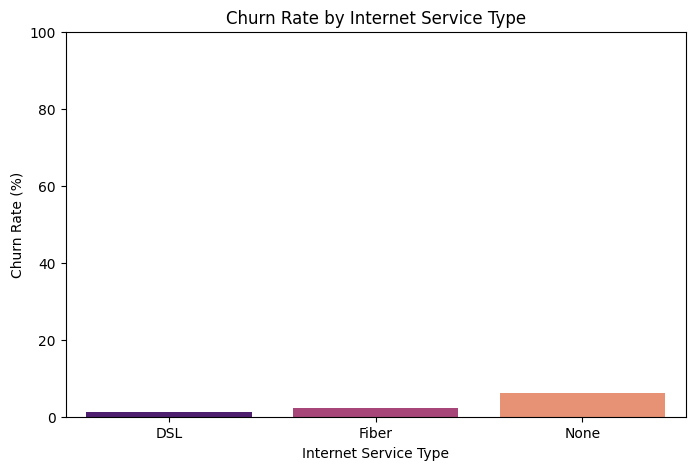

In [34]:
# Churn rate by Internet Service
internet_churn = df.groupby('Internet_Service')['Churn'].mean().reset_index()
internet_churn['Churn_Rate'] = internet_churn['Churn'] * 100

print("Churn Rate by Internet Service:")
print(internet_churn)

# Visualize churn rate by internet service
plt.figure(figsize=(8, 5))
sns.barplot(x='Internet_Service', y='Churn_Rate', data=internet_churn, palette='magma')
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

Churn Rate by Number of Support Calls:
    Support_Calls     Churn  Churn_Rate
0               0  0.000000    0.000000
1               1  0.000000    0.000000
2               2  0.000000    0.000000
3               3  0.000000    0.000000
4               4  0.038835    3.883495
5               5  0.061856    6.185567
6               6  0.044444    4.444444
7               7  0.051948    5.194805
8               8  0.092784    9.278351
9               9  0.025641    2.564103
10             10  0.022472    2.247191


/tmp/ipykernel_675/3651185723.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Support_Calls', y='Churn_Rate', data=support_calls_churn, palette='cividis')


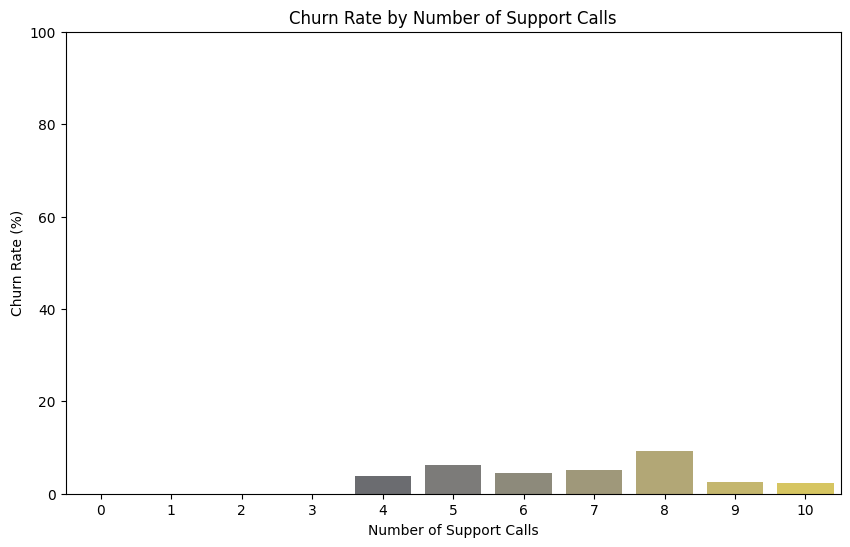

In [35]:
# Churn rate by Support Calls
support_calls_churn = df.groupby('Support_Calls')['Churn'].mean().reset_index()
support_calls_churn['Churn_Rate'] = support_calls_churn['Churn'] * 100

print("Churn Rate by Number of Support Calls:")
print(support_calls_churn)

# Visualize churn rate by support calls
plt.figure(figsize=(10, 6))
sns.barplot(x='Support_Calls', y='Churn_Rate', data=support_calls_churn, palette='cividis')
plt.title('Churn Rate by Number of Support Calls')
plt.xlabel('Number of Support Calls')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

/tmp/ipykernel_675/2928883392.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Monthly_Charges', data=df, palette='pastel')


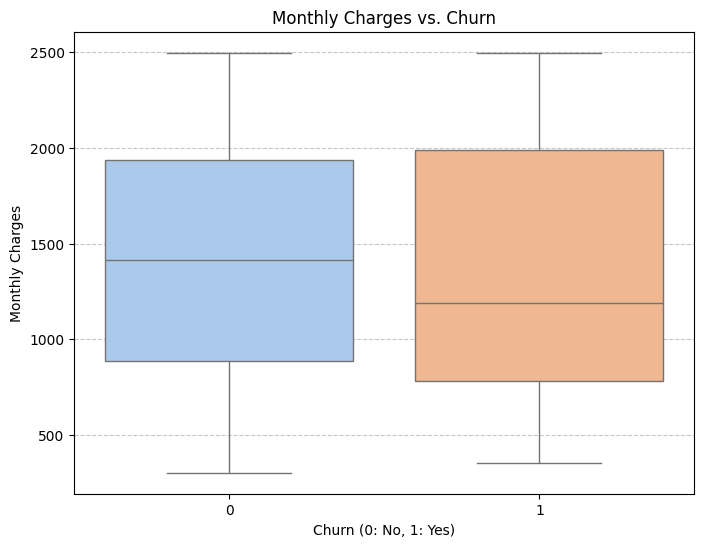

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Monthly_Charges', data=df, palette='pastel')
plt.title('Monthly Charges vs. Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Monthly Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_675/1262679452.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Total_Charges', data=df, palette='pastel')


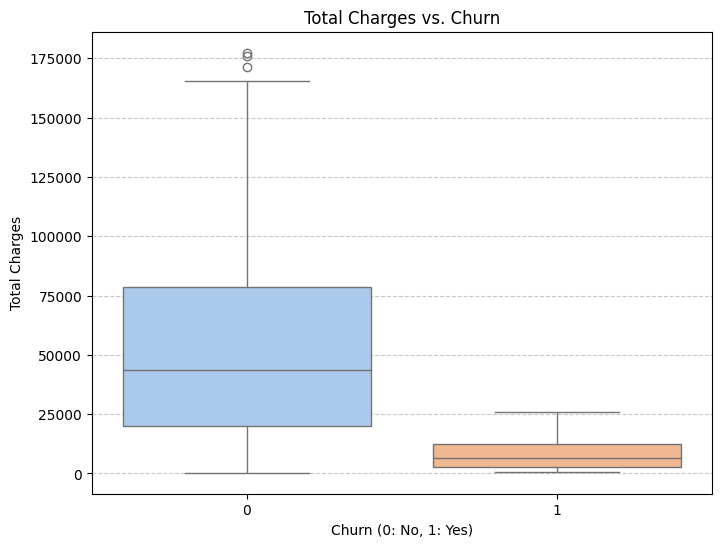

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Total_Charges', data=df, palette='pastel')
plt.title('Total Charges vs. Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Total Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_675/2611142513.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn', y='Tenure', data=df, palette='cool')


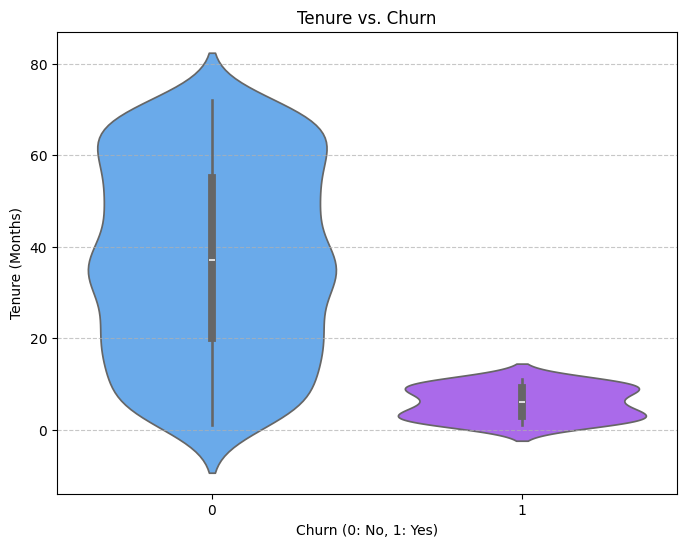

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.violinplot(x='Churn', y='Tenure', data=df, palette='cool')
plt.title('Tenure vs. Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Tenure (Months)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

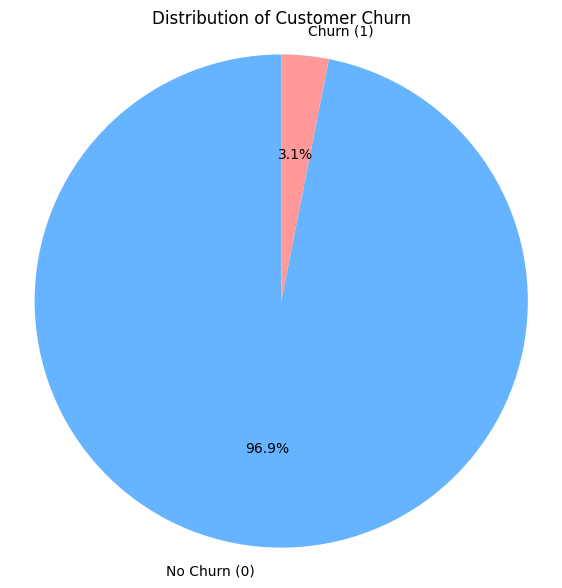

In [39]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(churn_counts, labels=['No Churn (0)', 'Churn (1)'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Distribution of Customer Churn')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

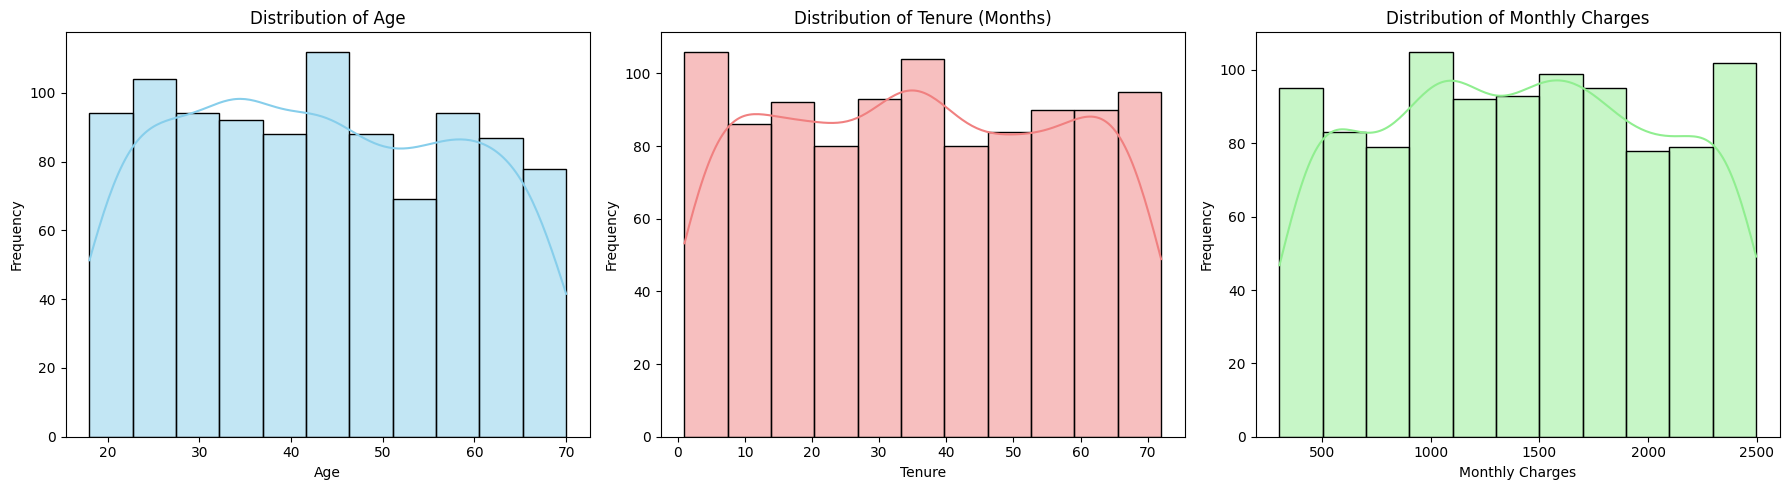

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

sns.histplot(df['Tenure'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Tenure (Months)')
axes[1].set_xlabel('Tenure')
axes[1].set_ylabel('Frequency')

sns.histplot(df['Monthly_Charges'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Monthly Charges')
axes[2].set_xlabel('Monthly Charges')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

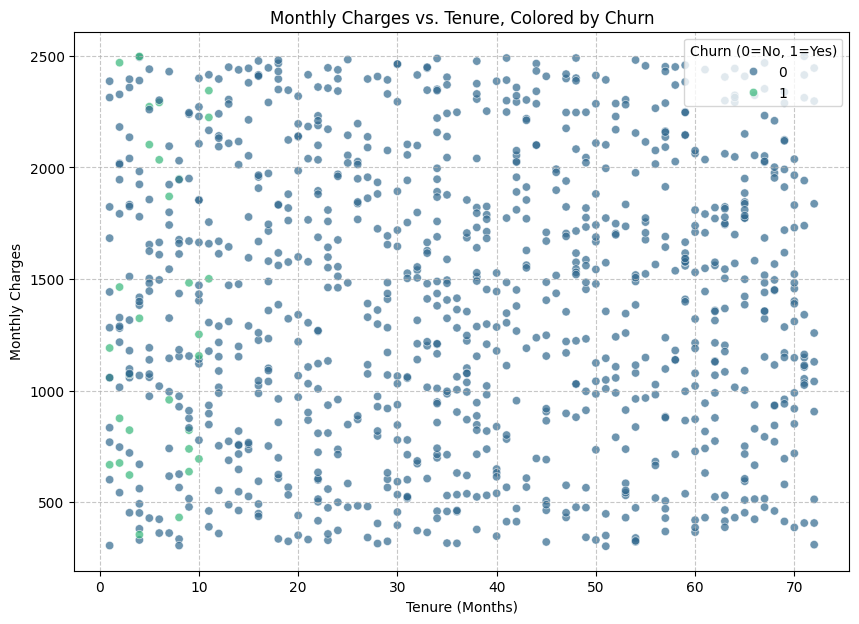

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Tenure', y='Monthly_Charges', hue='Churn', data=df, palette='viridis', alpha=0.7)
plt.title('Monthly Charges vs. Tenure, Colored by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Churn (0=No, 1=Yes)')
plt.show()

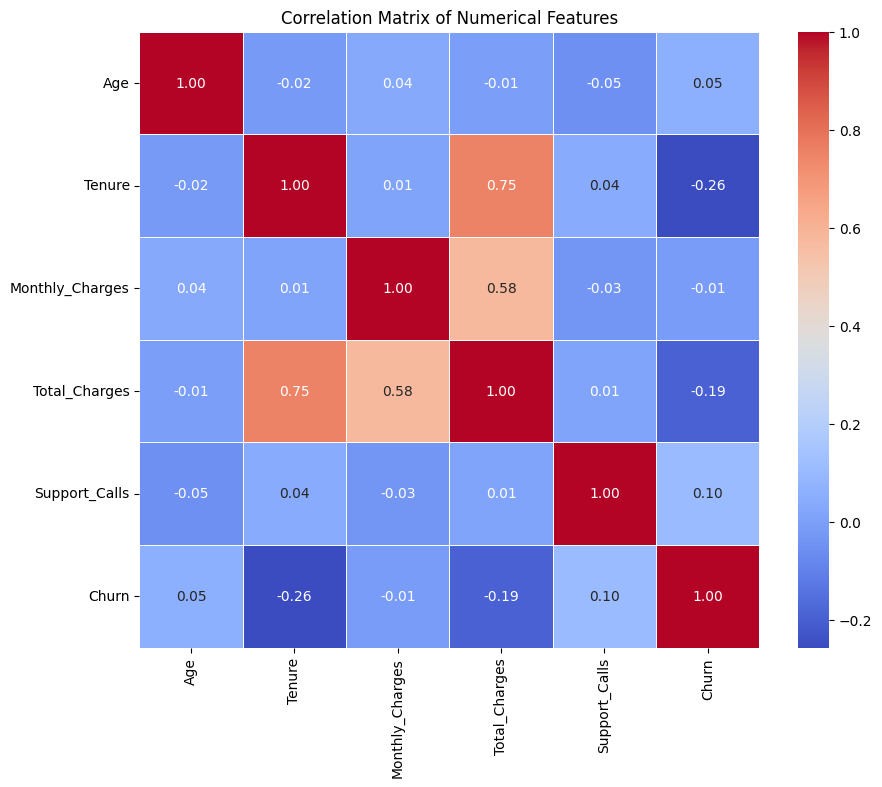

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()